# 1. Data loading and generators


In [47]:
# import zipfile
# import os
# from google.colab import drive
# drive.mount('/content/drive')

# print("Current directory:", os.getcwd())

# zip_path = '/content/drive/MyDrive/Colab Notebooks/Deep Learning/cats_dogs.zip'
# target_folder = '/content/drive/MyDrive/Colab Notebooks/Deep Learning/data'

# os.makedirs(target_folder, exist_ok=True)

# # Unzip into 'data' folder
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(target_folder)

import os, zipfile, urllib.request

URL = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip"

# 1. Download
urllib.request.urlretrieve(URL, "dogs_vs_cats.zip")
print("Downloaded:", os.path.getsize("dogs_vs_cats.zip") // 1_000_000, "MB")

# 2. Unzip into data/cats_dogs
os.makedirs("data/cats_dogs", exist_ok=True)
with zipfile.ZipFile("dogs_vs_cats.zip") as z:
    z.extractall("data/cats_dogs")

# 3. Some versions have nested train.zip / test.zip — unzip those too
for root, _, files in os.walk("data/cats_dogs"):
    for f in files:
        if f.endswith(".zip"):
            p = os.path.join(root, f)
            with zipfile.ZipFile(p) as z:
                z.extractall(root)
            os.remove(p)

# 4. Show the folder structure so you can confirm the paths
for root, dirs, files in os.walk("data/cats_dogs"):
    if root.replace("data/cats_dogs", "").count(os.sep) <= 2:
        print(root, "->", len(files), "files")

KeyboardInterrupt: 

In [48]:
IMG_HEIGHT, IMG_WIDTH = 64, 64
batch_size = 32
seed = 1337

In [49]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


np.random.seed(42); tf.random.set_seed(42)

# Paths - change if needed
DATA_ROOT = Path("data/cats_dogs")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        raise FileNotFoundError(f"No images found under {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

# Generators


train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)
# use plain training dataset without augmentation (only rescale)
train_gen_plain = ImageDataGenerator(rescale=1./255)
train_flow_plain = train_gen_plain.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
# Unlabeled test for inference only
test_flow = test_gen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})

Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 20000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


# 2. Inspect the data

To-Do: Write a short paragraph describing

The total number of training images per class from train_flow.class_indices and train_flow.labels.
Whether the classes are balanced or imbalanced.
Potential sources of visual variability like pose, scale, lighting, background.

In [50]:
print(train_flow.class_indices)
print(train_flow.labels[:5])
print(f'The total number of traning images for Cat is {train_flow.labels.count(train_flow.class_indices['cat'])}')
print(f'The total number of traning images for Dog is {train_flow.labels.count(train_flow.class_indices['dog'])}')
print('The number of images between 2 classes are balanced.')


{'cat': 0, 'dog': 1}
[0, 1, 1, 1, 1]
The total number of traning images for Cat is 10000
The total number of traning images for Dog is 10000
The number of images between 2 classes are balanced.


To-Do: Plot a small grid of training images and annotate each with its label.
Explain what visual cues might help the model distinguish cats from dogs.

X_batch shape: (32, 64, 64, 3)
X_batch min pixel value: 0.0, max pixel value: 1.0, dtype: float32
y_batch values: [0. 0. 0. 0. 1. 0. 1. 0. 1. 0.]
inv_class: {0: 'cat', 1: 'dog'}


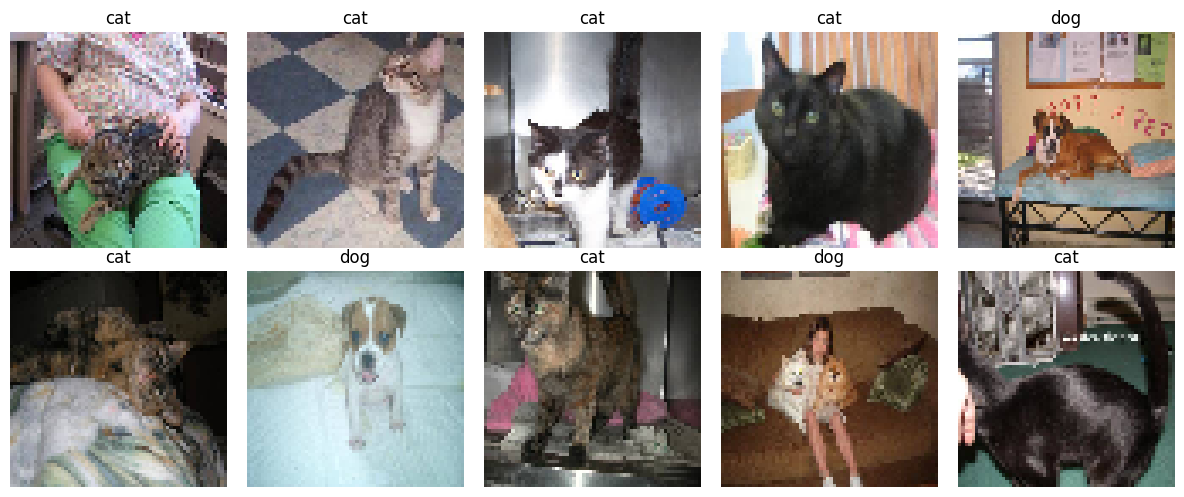

In [51]:
import matplotlib.pyplot as plt

# X_batch, y_batch = next(train_flow)  # load augmented new batches every time
# X_batch, y_batch = train_flow[0] # load the augmented first batch every time
X_batch, y_batch = train_flow_plain[0] # load the original dataset first batch every time

print(f"X_batch shape: {X_batch.shape}")
print(f"X_batch min pixel value: { X_batch.min()}, max pixel value: { X_batch.max()}, dtype: {X_batch.dtype}")

print(f"y_batch values: {y_batch[:10]}")
inv_class = {v: k for k, v in train_flow.class_indices.items()}
print(f"inv_class: {inv_class}")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, label in zip(axes.ravel(), X_batch, y_batch):
    ax.imshow(img)
    ax.set_title(inv_class[int(label)])
    ax.axis("off")
plt.tight_layout()
plt.show()

# 3. Define the model architecture
To-Do: Describe your planned CNN in full sentences before coding:

- Number of convolutional blocks and filter sizes.
- Placement of MaxPooling to reduce spatial dimensions.
- Use of Dropout and why it helps with regularization.
- Final Dense layers including the output layer with a single sigmoid unit for binary targets.

Our CNN workflow is as followings:

1. The CNN model will include 2 convolutional blocks with 3*3 filter and 'relu' activation function.
2. Each Conv2D will be followed by a MaxPooling for feature map dimension reducing and keeping the important info.
3. Then we will flat the last feature map to 1-D, apply Dense nerual network layer with 128 nerons and 'relu' as activation function
4. Use Dropput to prevent overfitting
5. Lastly, we use another Dense layer for output with sigmoid as activation function.

In [52]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_init_model():

    return keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPool2D((2, 2)),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPool2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),

        layers.Dropout(0.5), # helps prevent overfitting
        layers.Dense(1, activation='sigmoid')
    ])

# fresh model for plain data
model_plain = build_init_model()

# fresh model for augmented data
model_aug = build_init_model()


# 4. Choose the optimization setup
To-Do: Specify and justify

- Optimizer choice, recommended Adam for fast convergence.
- Initial learning rate and why it is reasonable.
- Batch size relative to GPU or CPU memory.
- EarlyStopping on validation loss and optional ReduceLROnPlateau to adapt learning rate.



For complition setup:
1. we will use 'adam' as optimizer.

    Because Adam (Adaptive Moment Estimation) combines two ideas that make it a strong default for CNNs:
      - Momentum — it keeps a running average of past gradients, smoothing out noisy updates and speeding convergence.
      - Per-parameter adaptive learning rates — it scales each weight's update by its own recent gradient magnitude (via a running average of squared gradients), so parameters that get small/sparse gradients (common in CNN filters) still get meaningful updates, while noisy/large-gradient parameters get dampened. Compared to plain SGD, this means Adam typically converges faster and needs much less manual learning-rate tuning — good for a project like this where we're iterating on architecture and don't want to spend a lot of time hand-tuning LR schedules.
2. Initial learning rate:  Adam's default learning_rate=0.001 (1e-3) is a well-tested starting point.
    Because it's:
      - High enough to make real progress in a reasonable number of epochs (important since you have 20k images and want epochs to not take forever)
      - Low enough to avoid the loss diverging/oscillating early in training, especially given the heavy augmentation (rotation up to 45°, zoom up to 0.5) we're applying — the training signal is already fairly noisy batch-to-batch, so a very high initial LR can compound that

3. we will use 'binary_crossentropy' as loss function
4. we will use 'accuracy' as validation metric.
5. Batch size should be as large as your hardware can handle without OOM errors, since larger batches mean fewer steps per epoch and better gradient estimates — but too large can hurt generalization slightly and obviously risks running out of memory. Smaller batch size means less memory needed per step (fewer images/activations held at once).
- Small batch → fits on weaker/smaller-memory hardware, but slower overall training (more steps, more overhead), and noisier gradient estimates
- Large batch → needs more memory (stronger GPU/more RAM), but faster training (fewer steps, better hardware utilization via parallelism), smoother gradients

6. EarlyStopping (on validation loss):

    Monitors val_loss after every epoch and stops training automatically once it stops improving, instead of running a fixed number of epochs regardless of whether the model is still learning. This directly protects against overfitting: past a certain point, training loss keeps dropping while validation loss starts rising (the model memorizes training data instead of generalizing)

7. ReduceLROnPlateau:
    
    Also monitors val_loss, but instead of stopping training, it shrinks the learning rate when validation loss plateaus (stops improving for patience epochs). The idea: a model that's stuck isn't necessarily done learning — it may just be stuck oscillating around a minimum because the current learning rate is too large to make finer adjustments. Lowering LR lets it take smaller, more precise steps and potentially keep improving.

In [53]:
model_plain.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the model
To-Do: Train for a fixed number of epochs, log training and validation curves, and then repeat with early stopping enabled.

Explain how you detect overfitting from the curves and what change you make to mitigate it.

In [54]:
history_plain = model_plain.fit(train_flow_plain, validation_data=val_flow, epochs=15)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 268ms/step - accuracy: 0.6832 - loss: 0.6315 - val_accuracy: 0.7234 - val_loss: 0.5522
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 243ms/step - accuracy: 0.7695 - loss: 0.4795 - val_accuracy: 0.5976 - val_loss: 0.7008
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 236ms/step - accuracy: 0.8062 - loss: 0.4228 - val_accuracy: 0.7662 - val_loss: 0.4864
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 211s 337ms/step - accuracy: 0.8372 - loss: 0.3705 - val_accuracy: 0.7960 - val_loss: 0.4381
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 172s 276ms/step - accuracy: 0.8628 - loss: 0.3198 - val_accuracy: 0.7826 - val_loss: 0.5558
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 258ms/step - accuracy: 0.8817 - loss: 0.2789 - val_accuracy: 0.7814 - val_loss: 0.5546
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.9115 - loss: 0.2222 - val_accuracy: 0.8070 - val_loss: 0.4549
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 272ms/step - accuracy: 0.9064 -

In [55]:
history_aug = model_aug.fit(train_flow, validation_data=val_flow, epochs=15)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 187s 295ms/step - accuracy: 0.6053 - loss: 0.7372 - val_accuracy: 0.6228 - val_loss: 0.6409
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 183s 293ms/step - accuracy: 0.6643 - loss: 0.6085 - val_accuracy: 0.7148 - val_loss: 0.5502
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 179s 287ms/step - accuracy: 0.7008 - loss: 0.5716 - val_accuracy: 0.6848 - val_loss: 0.6139
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 278ms/step - accuracy: 0.7158 - loss: 0.5525 - val_accuracy: 0.7160 - val_loss: 0.5435
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 283ms/step - accuracy: 0.7247 - loss: 0.5404 - val_accuracy: 0.7332 - val_loss: 0.5171
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 175s 281ms/step - accuracy: 0.7371 - loss: 0.5246 - val_accuracy: 0.7258 - val_loss: 0.5471
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 180s 288ms/step - accuracy: 0.7443 - loss: 0.5115 - val_accuracy: 0.7312 - val_loss: 0.5471
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 281ms/step - accuracy: 0.7519 -

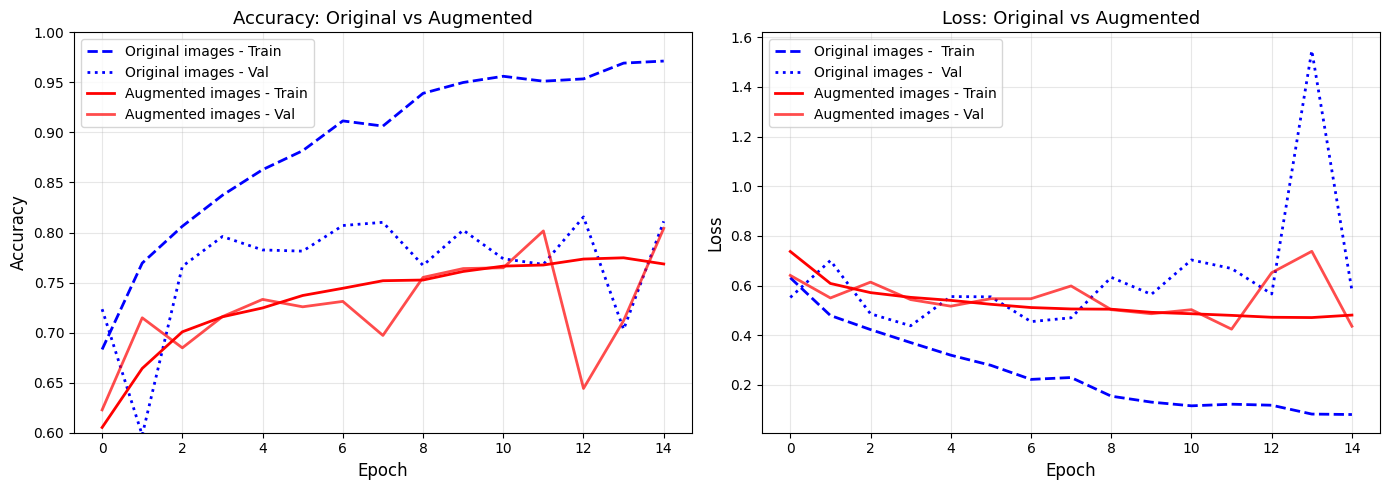

In [57]:
# Visualize training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_plain.history['accuracy'], 'b--', label='Original images - Train', linewidth=2)
axes[0].plot(history_plain.history['val_accuracy'], 'b:', label='Original images - Val', linewidth=2)
axes[0].plot(history_aug.history['accuracy'], 'r-', label='Augmented images - Train', linewidth=2)
axes[0].plot(history_aug.history['val_accuracy'], 'r-', label='Augmented images - Val', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy: Original vs Augmented', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.6, 1.0])

# Loss comparison
axes[1].plot(history_plain.history['loss'], 'b--', label='Original images -  Train', linewidth=2)
axes[1].plot(history_plain.history['val_loss'], 'b:', label='Original images -  Val', linewidth=2)
axes[1].plot(history_aug.history['loss'], 'r-', label='Augmented images - Train', linewidth=2)
axes[1].plot(history_aug.history['val_loss'], 'r-', label='Augmented images - Val', linewidth=2, alpha=0.7)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss: Original vs Augmented', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [58]:
print("KEY OBSERVATIONS:")
print("  • CNN model trained on original dataset reaches higher accuracy faster and lower loss (more confident predictions). But we can see the accuracy on validation dataset not getting improved after epoch 3, which means traning after epoch 3 was overfitting.")
print("  • CNN model trained on augmented dataset has a slower climb on accuracy, val_acc not imporved much after epoch 4-5, loss curve shows no significant decay at the same time")

print("When the gap between training and validation curve becomes bigger, that means it's overfitting.")

KEY OBSERVATIONS:
  • CNN model trained on original dataset reaches higher accuracy faster and lower loss (more confident predictions). But we can see the accuracy on validation dataset not getting improved after epoch 3, which means traning after epoch 3 was overfitting.
  • CNN model trained on augmented dataset has a slower climb on accuracy, val_acc not imporved much after epoch 4-5, loss curve shows no significant decay at the same time


In [59]:
# retrain with early stopping enabled
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                  # stop if val_loss doesn't improve for 5 epochs
    restore_best_weights=True    # roll back to the best epoch's weights
)

model_plain_es = build_init_model()

model_plain_es.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_plain_es = model_plain_es.fit(
    train_flow_plain,
    validation_data=val_flow,
    epochs=15,                   # set a higher cap since EarlyStopping will cut it short anyway
    callbacks=[early_stop]
)



Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 235ms/step - accuracy: 0.6953 - loss: 0.6138 - val_accuracy: 0.7432 - val_loss: 0.5545
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 154s 246ms/step - accuracy: 0.7821 - loss: 0.4651 - val_accuracy: 0.7280 - val_loss: 0.5752
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 247ms/step - accuracy: 0.8152 - loss: 0.4065 - val_accuracy: 0.7530 - val_loss: 0.5073
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 154s 247ms/step - accuracy: 0.8450 - loss: 0.3502 - val_accuracy: 0.7754 - val_loss: 0.4936
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.8679 - loss: 0.3056 - val_accuracy: 0.7234 - val_loss: 0.6977
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 272ms/step - accuracy: 0.8946 - loss: 0.2543 - val_accuracy: 0.7900 - val_loss: 0.5001
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 211s 338ms/step - accuracy: 0.9085 - loss: 0.2222 - val_accuracy: 0.8158 - val_loss: 0.4386
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 260ms/step - accuracy: 0.9306 -

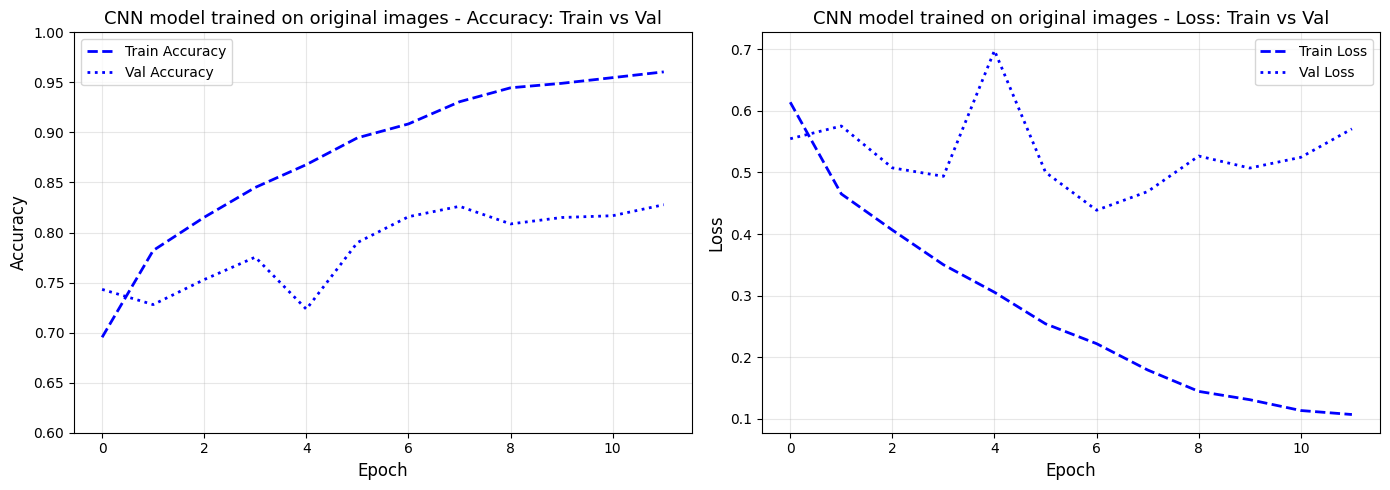

In [60]:
# Visualize training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_plain_es.history['accuracy'], 'b--', label='Train Accuracy', linewidth=2)
axes[0].plot(history_plain_es.history['val_accuracy'], 'b:', label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('CNN model trained on original images - Accuracy: Train vs Val', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.6, 1.0])

# Loss comparison
axes[1].plot(history_plain_es.history['loss'], 'b--', label='Train Loss', linewidth=2)
axes[1].plot(history_plain_es.history['val_loss'], 'b:', label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('CNN model trained on original images - Loss: Train vs Val', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# 6. Evaluate on validation data
To-Do: Compute and report

- Validation accuracy and loss.
- A confusion matrix and class wise precision and recall on the validation set.

In [64]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

base_threshold = 0.3
val_flow.reset()  # ensure iterator starts from batch 0, matches label order
y_val_pred_proba = model_plain.predict(val_flow, steps=math.ceil(val_flow.samples / batch_size))

y_val_true = val_flow.labels  # true labels in the same fixed order (shuffle=False)
class_names = list(val_flow.class_indices.keys())


157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step


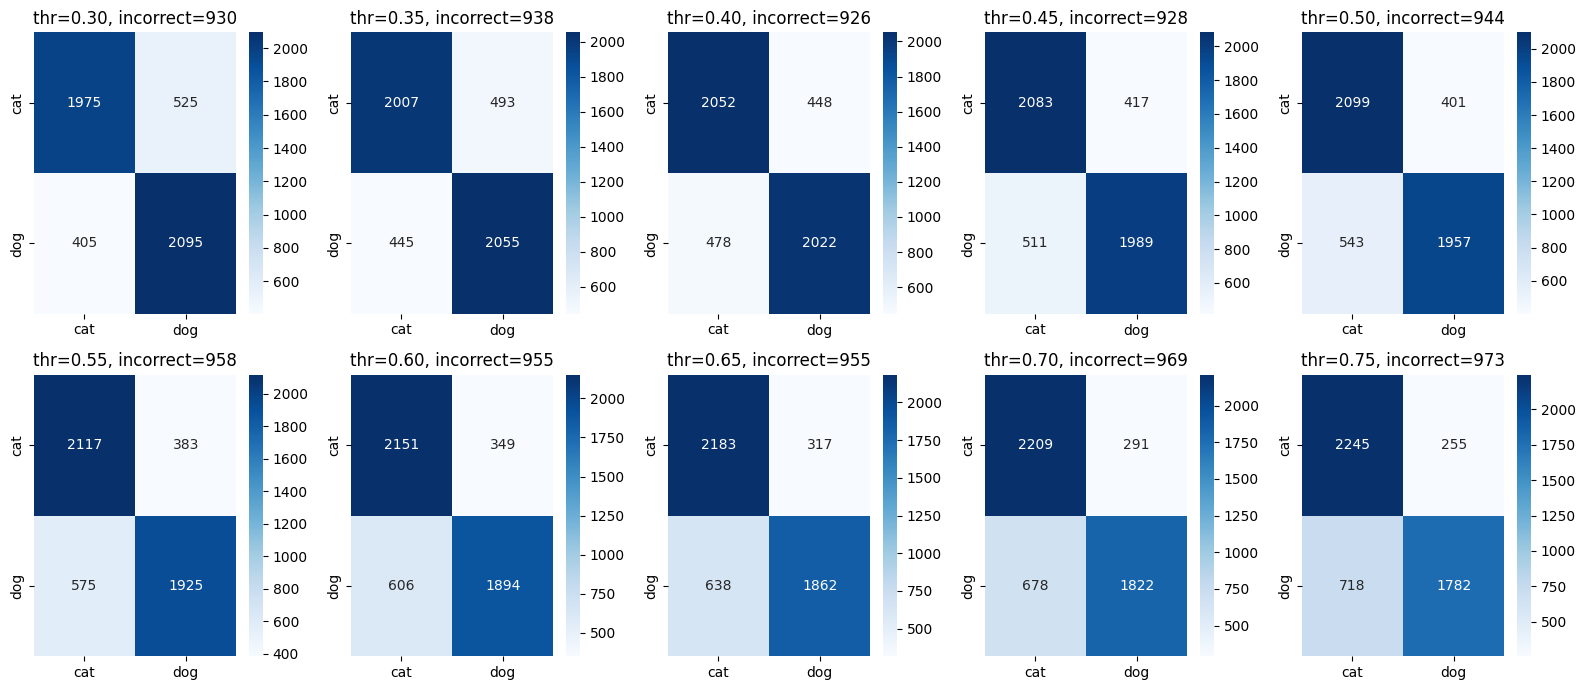

              precision    recall  f1-score   support

         cat       0.76      0.90      0.82      2500
         dog       0.87      0.71      0.79      2500

    accuracy                           0.81      5000
   macro avg       0.82      0.81      0.80      5000
weighted avg       0.82      0.81      0.80      5000



In [74]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()
base_threshold = 0.30
for i in range(10):
  threshold = base_threshold + 0.05 * i
  y_val_pred = (y_val_pred_proba > threshold).astype(int).ravel()
  cm_plain_val = confusion_matrix(y_val_true, y_val_pred)
  sns.heatmap(cm_plain_val, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[i])
  axes[i].set_title(f"thr={threshold:.2f}, incorrect={cm_plain_val[0, 1]+ cm_plain_val[1, 0]}")


plt.tight_layout()
plt.show()

print(classification_report(y_val_true, y_val_pred, target_names=class_names))

According to the confusion matrix charts with differrent threshold, i think when threshold = 0.4, we get better prediction, less incorrect cases and more balanced classification between dogs and cats

# 7. Run inference on the unlabeled test set
To-Do: Use the trained model to produce probabilities for the test iterator and convert them to labels using a threshold you justify. Save a CSV with columns

- filepath
- prob_dog
- pred_label

Explain how you would verify a subset manually to sanity check outputs.

Why: Reproducible exports and traceability back to file paths are essential for audits and error analysis.

In [75]:
y_test_pred_proba = model_plain.predict(test_flow)

threshold = 0.4
y_test_pred = (y_test_pred_proba > threshold).astype(int).ravel()


result_df = pd.DataFrame({
    'filepath': test_flow.filenames,
    'prob_dog': y_test_pred_proba.ravel(),
    'pred_label': [inv_class[label] for label in y_test_pred]
})

result_df.to_csv("test_prediction.csv", index=False)
result_df.head()





391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step


,filepath,prob_dog,pred_label
0,data/cats_dogs/test/test/5433.jpg,4.907993e-01,dog
1,data/cats_dogs/test/test/3766.jpg,6.019361e-01,dog
2,data/cats_dogs/test/test/1741.jpg,3.017963e-01,cat
3,data/cats_dogs/test/test/3650.jpg,5.825927e-01,dog
4,data/cats_dogs/test/test/10748.jpg,3.433972e-07,cat


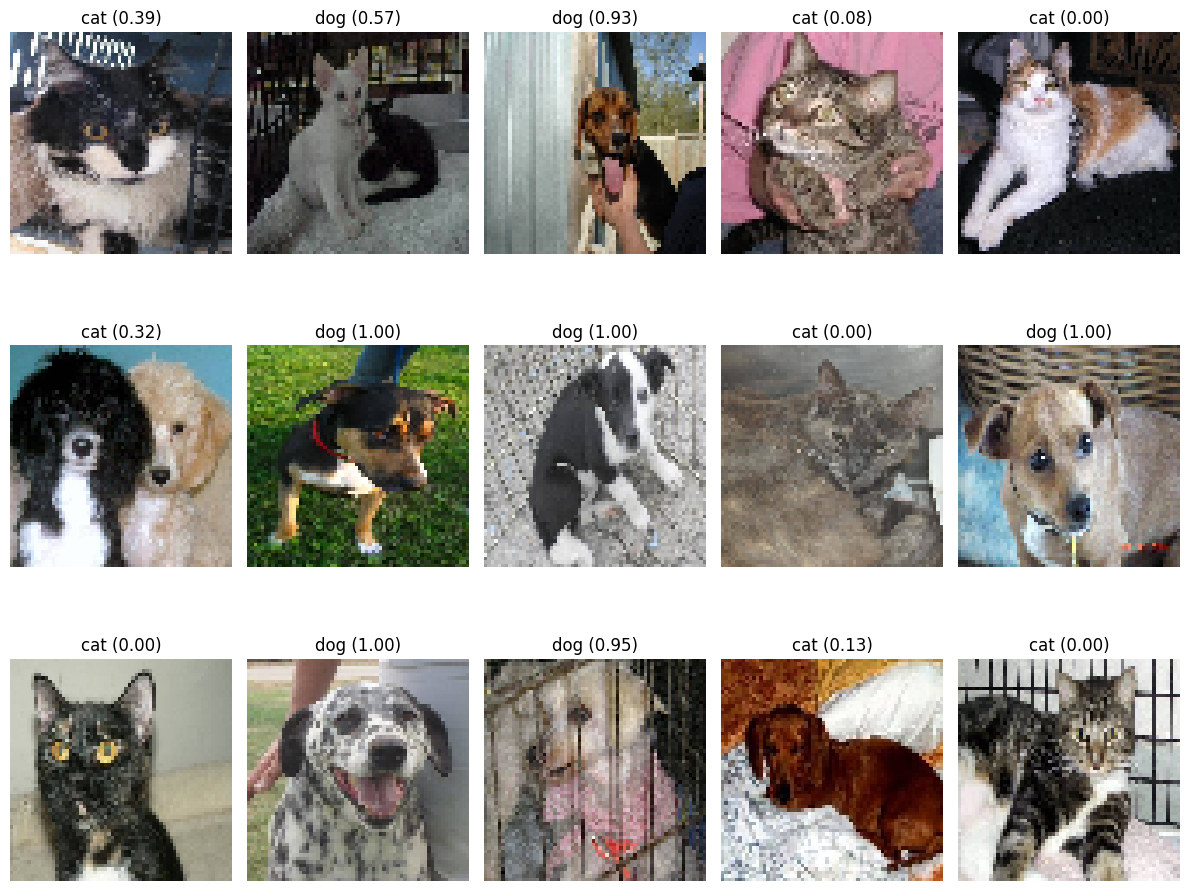

In [83]:
# Let's verify 10 test images, see if the predicted label is correct or not
from tensorflow.keras.preprocessing.image import load_img

sample_df = result_df.sample(15)

fig, axes = plt.subplots(3, 5, figsize=(12, 10))
for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    img = load_img(row['filepath'], target_size=(IMG_HEIGHT, IMG_WIDTH))
    ax.imshow(img)
    ax.set_title(f"{row['pred_label']} ({row['prob_dog']:.2f})")
    ax.axis("off")
plt.tight_layout()
plt.show()


From the sampled test images, we see that most of images as identified correctly, only the 2nd was wrongly labeled as Dog, and the 6th and 14th were wrongly labeld as Cat. Due to the low resolution, the result is relatively good.

# 8. Compare baseline vs augmentation
To-Do: Train a baseline model with identical architecture but no augmentation.


Compare validation metrics and learning curves to the augmented model.
Write a brief analysis of the generalization gap.

Why: Ablations isolate which choices drive performance. Augmentation often improves robustness without increasing parameters.

Learning point: Prefer changes that improve validation performance without large increases in train compute. Augmentation is one such change.


Already done in step 3-5, I trained 2 models, one without augmentation, one with augmentation, the results were plotted and analysis were given.

# 9. Class imbalance handling
To-Do: If classes are imbalanced, compute class weights and retrain using class_weight.

Explain the effect on precision and recall for the minority class.

Why: Balanced loss contributions prevent the network from favoring the majority class.

If classes are imbalanced, we can compute class weights:

```
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_flow.labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_flow.labels
)
class_weight_dict = dict(zip(classes, class_weights))

model_weighted.fit(
    train_flow_plain,
    ...,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
```

- Minority class recall increases — the model becomes less biased toward predicting the majority class, catching more true minority-class instances it would've otherwise missed
- Minority class precision may decrease slightly — because the model becomes more willing to predict the minority class, it also produces more false positives for that class
- Majority class precision/recall can shift the opposite way — trading some majority-class accuracy for better minority-class detection




# 10. Save artifacts for reuse
To-Do: Save the best model to disk in H5 or SavedModel format and record the training configuration in a small YAML or JSON.

Explain why saving both weights and metadata is necessary for reproducibility.

In [84]:
import json
from datetime import datetime

# 1. Save the model - Keras native format (recommended over H5 for TF2.x)
model_plain_es.save("best_model.keras")
# or, if H5 is specifically required:
# model_plain_es.save("best_model.h5")

# 2. Record training configuration
config = {
    "timestamp": datetime.now().isoformat(),
    "model_file": "best_model.keras",
    "image_size": [IMG_HEIGHT, IMG_WIDTH],
    "batch_size": batch_size,
    "architecture": "2 conv blocks (32, 64 filters) + BatchNorm + MaxPool, Dense(128) + Dropout(0.5), sigmoid output",
    "optimizer": "adam",
    "learning_rate": 0.001,
    "loss": "binary_crossentropy",
    "metrics": ["accuracy"],
    "augmentation": False,
    "callbacks": {
        "early_stopping": {
            "monitor": "val_loss",
            "patience": 5,
            "restore_best_weights": True
        }
    },
    "epochs_trained": len(history_plain_es.history["loss"]),
    "final_val_accuracy": history_plain_es.history["val_accuracy"][-1],
    "final_val_loss": history_plain_es.history["val_loss"][-1],
    "prediction_threshold": 0.4,
    "class_indices": train_flow.class_indices,
}

with open("training_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "timestamp": "2026-07-07T14:34:14.162338",
  "model_file": "best_model.keras",
  "image_size": [
    64,
    64
  ],
  "batch_size": 32,
  "architecture": "2 conv blocks (32, 64 filters) + BatchNorm + MaxPool, Dense(128) + Dropout(0.5), sigmoid output",
  "optimizer": "adam",
  "learning_rate": 0.001,
  "loss": "binary_crossentropy",
  "metrics": [
    "accuracy"
  ],
  "augmentation": false,
  "callbacks": {
    "early_stopping": {
      "monitor": "val_loss",
      "patience": 5,
      "restore_best_weights": true
    }
  },
  "epochs_trained": 12,
  "final_val_accuracy": 0.8277999758720398,
  "final_val_loss": 0.570553183555603,
  "prediction_threshold": 0.4,
  "class_indices": {
    "cat": 0,
    "dog": 1
  }
}


# 11. Extensions
To-Do: Propose one of the following and justify the expected benefit

Batch Normalization after convolutions.
Transfer learning with a frozen lightweight backbone like MobileNetV2 and a small classifier head.
Mixed precision training to accelerate on modern GPUs.

Why: These techniques can yield better accuracy or faster training with limited additional code.

Learning point: Transfer learning provides strong priors for low level features like edges and textures which are common across natural images. Fine tuning later layers adapts to the new task.